In [9]:
!pip install git-filter-repo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.3/76.3 kB 4.7 MB/s eta 0:00:00


In [14]:
import os

# make a working directory for the cleanup work
!mkdir -p /tmp/Quantum-Area-Law-Evaluation
%cd /tmp/Quantum-Area-Law-Evaluation

# mirror clone (includes all refs, tags, and branches)
!git clone --mirror https://github.com/esessler313/Quantum-Area-Law-Evaluation.git Quantum-Area-Law-Evaluation.git

# create a backup copy in case you need to restore
!cp -a Quantum-Area-Law-Evaluation.git Quantum-Area-Law-Evaluation.git.bak

# Change into the cloned repository directory
%cd Quantum-Area-Law-Evaluation.git

/tmp/Quantum-Area-Law-Evaluation
fatal: destination path 'Quantum-Area-Law-Evaluation.git' already exists and is not an empty directory.
/tmp/Quantum-Area-Law-Evaluation/Quantum-Area-Law-Evaluation.git


In [16]:
# Create a file 'secrets.txt' with the exact token replaced by [REDACTED]
# Note: the format is "OLD_TEXT==>NEW_TEXT" per git-filter-repo --replace-text
!printf '%s==> %s\n' 'UXeigmyCo1glM3qbVJtBKW2cdQi8NiRAuPeaf7ePqW8X' '[REDACTED]' > secrets.txt
# (Optional) inspect
!cat secrets.txt

UXeigmyCo1glM3qbVJtBKW2cdQi8NiRAuPeaf7ePqW8X==> [REDACTED]


### Run `git-filter-repo` to clean history

**WARNING**: This command rewrites your Git history. Ensure you understand the implications before proceeding. If you have already pushed your repository to GitHub, you will need to force push after this operation.

In [19]:
# This command will rewrite the repository's history to replace the secret token
# with [REDACTED] wherever it appears in commit messages, file contents, etc.
# The '--force' is often needed when working in a non-standard git environment like Colab.
!git filter-repo --replace-text secrets.txt --force

print("Repository history has been rewritten. You may need to force push to GitHub.")

NOTICE: Removing 'origin' remote; see 'Why is my origin removed?'
        in the manual if you want to push back there.
        (was https://github.com/esessler313/Quantum-Area-Law-Evaluation.git)
Note: A branch outside the refs/remotes/ hierarchy was not removed;
to delete it, use:
  git branch -d main
Parsed 5 commits
New history written in 0.23 seconds; now repacking/cleaning...
Repacking your repo and cleaning out old unneeded objects
Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (12/12), done.
Writing objects: 100% (13/13), done.
Building bitmaps: 100% (5/5), done.
Total 13 (delta 2), reused 3 (delta 0), pack-reused 0
Completely finished after 0.37 seconds.
Repository history has been rewritten. You may need to force push to GitHub.


In [17]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib pylatexenc
from qiskit_ibm_runtime import QiskitRuntimeService
token = "UXeigmyCo1glM3qbVJtBKW2cdQi8NiRAuPeaf7ePqW8X" # This is API key for IBM Quantum account. Get it from https://quantum-computing.ibm.com/account
QiskitRuntimeService.save_account(
  token=token, # API key for IBM Quantum account, using the 'token' variable.
  channel="ibm_cloud", # `channel` distinguishes between different account types.
  instance="crn:v1:bluemix:public:quantum-computing:us-east:a/33cedef05e7440c696f57468f5d7f109:96ce53c2-e589-4808-b39c-a24e2bfce314::", # Optionally copy the instance CRN or name from the Instance section on the dashboard.
  name="Sessler_Aggregator", # Optionally name this set of credentials. # Only needed if you already have Cloud credentials.
  overwrite=True)

In [2]:
ibm_service = QiskitRuntimeService(name="Sessler_Aggregator")
ibmq_comp = ibm_service.backend('ibm_fez')

Created a 10-qubit brickwork circuit of depth 10.


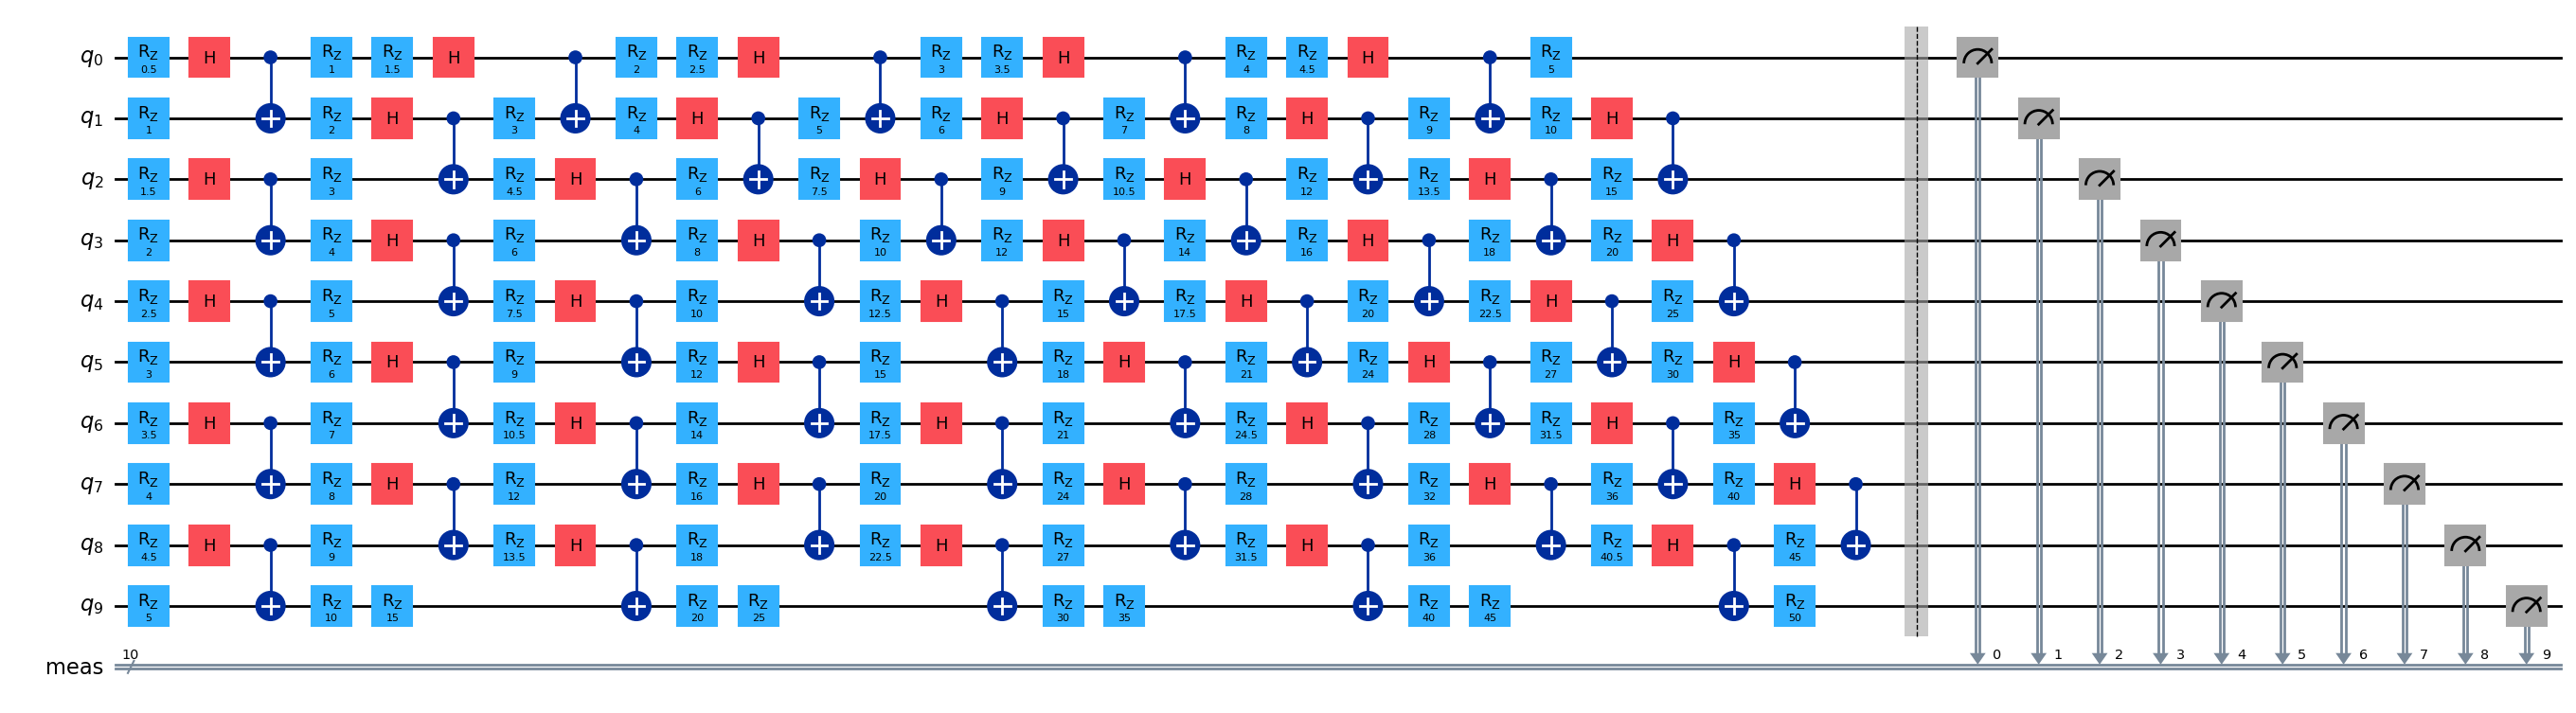

In [3]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import RZGate

def create_brickwork_entanglement_circuit(num_qubits, depth=10):

    qc = QuantumCircuit(num_qubits)

    for layer in range(depth):
        # Apply single-qubit rotations (RZ) to all qubits
        for i in range(num_qubits):
            qc.rz(0.5 * (layer + 1) * (i + 1), i) # Simple rotation for variety

        # Alternating entanglement layers
        if layer % 2 == 0: # Even layers entangle (0,1), (2,3), etc.
            for i in range(0, num_qubits - 1, 2):
                qc.h(i)      # Apply Hadamard to the even-indexed qubit
                qc.cx(i, i+1) # Apply CNOT between the even and the next odd-indexed qubit
        else: # Odd layers entangle (1,2), (3,4), etc.
            for i in range(1, num_qubits - 1, 2):
                qc.h(i)      # Apply Hadamard to the odd-indexed qubit
                qc.cx(i, i+1) # Apply CNOT between the odd and the next even-indexed qubit
    return qc

# Create a 10-qubit circuit with brickwork entanglement and depth 10
num_qubits = 10
circuit_depth = 10
brickwork_circuit = create_brickwork_entanglement_circuit(num_qubits, depth=circuit_depth)
brickwork_circuit.measure_all()
# Draw the circuit
print(f"Created a {num_qubits}-qubit brickwork circuit of depth {circuit_depth}.")
brickwork_circuit.draw('mpl', filename='brickwork_circuit.png', fold=-1) # Save to file to avoid large stdout in notebook


In [4]:
from qiskit_aer import AerSimulator
Asimulate = AerSimulator()

In [5]:
from qiskit_ibm_runtime import SamplerV2
sampler_aer = SamplerV2(mode=Asimulate)
sampler_ibm = SamplerV2(mode=ibmq_comp)

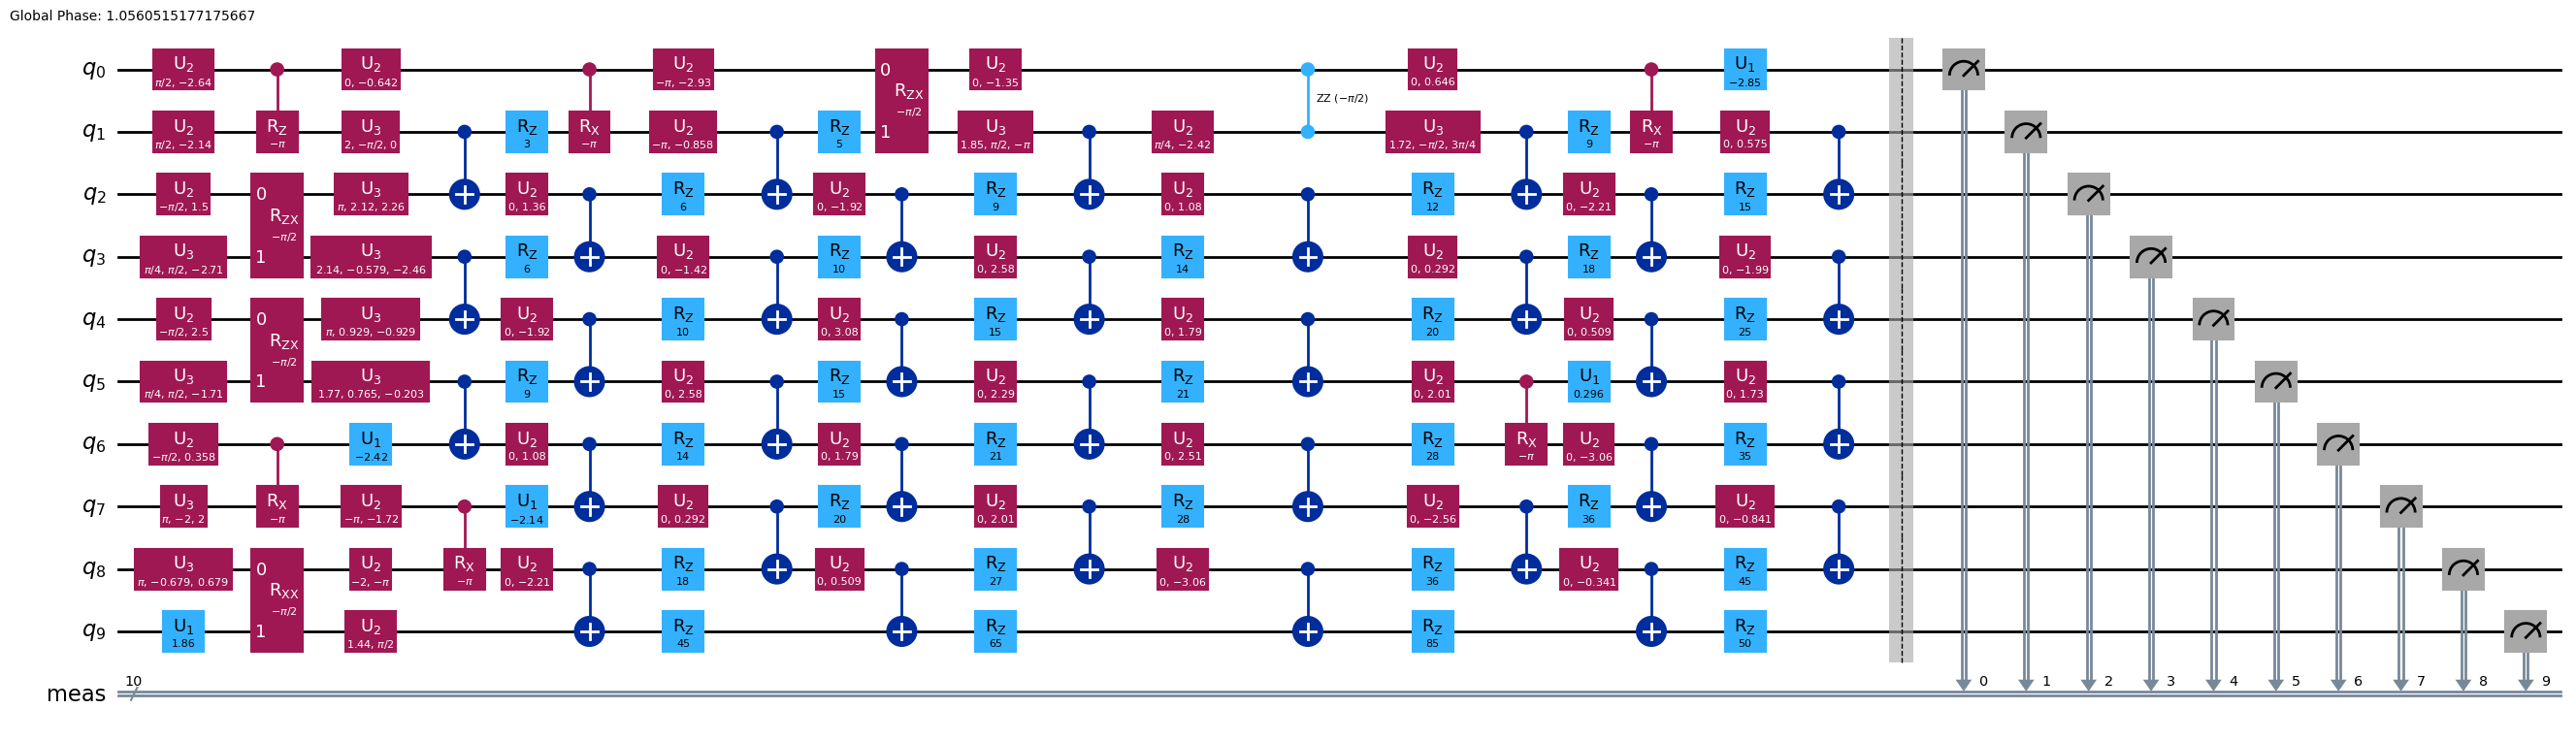

In [7]:
from qiskit import transpile
qc1_aer = transpile(brickwork_circuit, Asimulate) #Always transpile first, translates the language for the quantum computer
qc1_aer.draw('mpl',fold=-1)

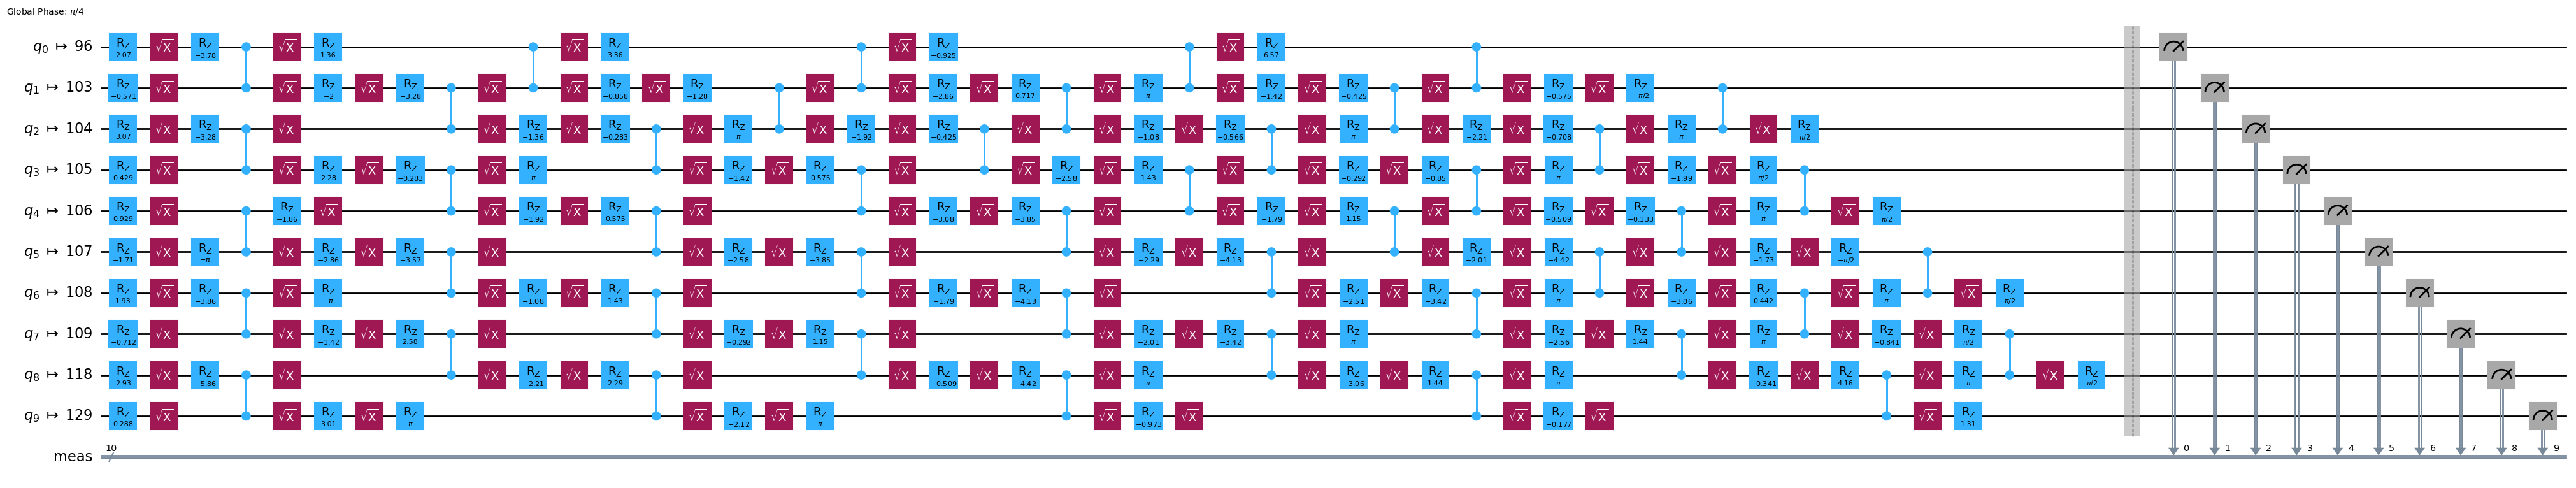

In [8]:
qc1_ibm = transpile(brickwork_circuit, ibmq_comp) #Circuit, then simulator
qc1_ibm.draw('mpl',idle_wires=False, fold =-1)

In [ ]:
job_aer = sampler_aer.run([(qc1_aer,None, 10000)])  #PUBs on AER simulator
job_ibm = sampler_ibm.run([(qc1_ibm,None, 10000)])  #PUBs on IBMQ

In [ ]:
result_aer = job_aer.result()
result_ibm = job_ibm.result()

In [ ]:
from qiskit.visualization import plot_histogram, plot_distribution
counts_qc1_aer = result_aer[0].data.meas.get_counts()
counts_qc1_ibm = result_ibm[0].data.meas.get_counts()
plot_distribution([counts_qc1_aer,counts_qc1_ibm], legend=['Aer', 'IBM'])

In [ ]:

counts_qc2_aer = result_aer[0].data.meas.get_counts()
counts_qc2_ibm = result_ibm[0].data.meas.get_counts()

plot_distribution([counts_qc2_aer,counts_qc2_ibm], legend=['Aer', 'IBM'])

### Interpretation of Results

Based on the generated plot of entanglement entropy versus subsystem size for both noiseless and noisy simulations, we can make the following observations:

*   **Noiseless Simulation:** In an ideal, noiseless scenario, we typically expect a quantum chaotic system (like a brickwork circuit with random-like unitary gates) to exhibit a **volume-law** scaling of entanglement entropy. This means the entanglement entropy $S(A)$ grows proportionally to the size of the subsystem $k$. For small subsystems, the entropy often increases rapidly and then tends to saturate at a value close to the theoretical maximum for a maximally entangled state ($k \log 2$). This indicates strong entanglement generation throughout the circuit.



In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import partial_trace
from qiskit.quantum_info import Statevector # Import Statevector to represent quantum states
from qiskit.quantum_info import entropy # Import entropy to calculate entanglement entropy

# Create a quantum circuit with 8 qubits

Qc = QuantumCircuit(10)
x = Parameter('x')
num_qubits = 10

SVsampler = StatevectorSampler() # Initialize StatevectorSampler without the circuit

# Apply gates to the circuit to create alternating entanglement
for i in range(0, num_qubits - 1, 2):
        Qc.h(i)      # Apply Hadamard to the even-indexed qubit
        Qc.cx(i, i+1) # Apply CNOT between the even and the next odd-indexed qubit

# Now, simulate the circuit to get the statevector
# We use Statevector.from_circuit to get the ideal statevector of the circuit.
state_vector = Statevector.from_circuit(Qc)

# Perform the partial trace on the obtained state_vector
# For example, tracing out qubit 0
reduced_rho = partial_trace(state_vector, [0])
entanglement_entropy = entropy(reduced_rho, base=2)
Qc.draw('mpl')

print("Reduced Density Matrix after partial trace on qubit 0:")
print(reduced_rho)
print("Entanglement Entropy:", entanglement_entropy)


In [ ]:
Qc.draw('mpl')

### Entanglement Entropy for varying Subsystem Sizes

Let's now compute the von Neumann entanglement entropy for subsystems of varying sizes. We will consider subsystems consisting of the first $k$ qubits, for $k = 1, 2, \dots, n/2$ (where $n$ is the total number of qubits).

In [ ]:
# Store entanglement entropies
entropies = []

# Iterate for subsystem sizes k from 1 to num_qubits // 2
for k in range(1, num_qubits // 2 + 1):
    # Define the qubits to trace out. These are qubits from k to num_qubits - 1.
    # In partial_trace, if we provide the indices to keep, it traces out the others.
    # So we want to keep qubits 0 to k-1.
    # The partial_trace function expects the indices of the qubits to trace out.
    # So, we trace out qubits from k up to num_qubits-1.
    qubits_to_trace_out = list(range(k, num_qubits))

    # Calculate the reduced density matrix by tracing out the specified qubits
    reduced_density_matrix = partial_trace(state_vector, qubits_to_trace_out)

    # Calculate the von Neumann entropy of the reduced density matrix
    ent_entropy = entropy(reduced_density_matrix, base=2)
    entropies.append((k, ent_entropy))

    print(f"For a subsystem of the first {k} qubits (tracing out {num_qubits - k} qubits):")
    print(f"  Reduced Density Matrix:\n{reduced_density_matrix}")
    print(f"  Entanglement Entropy: {ent_entropy}\n")

# Optionally, display all calculated entropies in a more structured way
print("Summary of Entanglement Entropies:")
for k_val, ent_val in entropies:
    print(f"  k = {k_val}: Entropy = {ent_val}")